In [11]:
import pandas as pd
import pysam
import os
import json

# assemblies

In [12]:
assemblyDict={}
directory='/LeeLab/Assemblies/HPRC_Release2/chrY_assemblies/'
for file in os.listdir(directory):
    if '.fai' in file or '.gzi' in file or '.DS' in file:
        continue
    else:
        assemblyDict[file.split("_")[0]]= directory+file
print(len(assemblyDict))

143


In [13]:
df = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/DavidPorubsky/AZFc_ColorBLock_Clusters_12162025.csv")

# RepeatMasker

In [14]:
rmDict={}
directory='/LeeLab/HPRC/chromosomeY/Data/RepeatMasker/'
for file in os.listdir(directory):
    rmDict[file.split(".")[0]]=directory+file

## Read in MSA

In [15]:
from __future__ import annotations

from pathlib import Path
from typing import Union, List, Dict
import pandas as pd


def msa_fasta_to_df(
    fasta_path: Union[str, Path],
    *,
    long: bool = False,
    keep_gaps: bool = True,
    fill_value: str = "-",
) -> pd.DataFrame:
    """
    Read a multi-sequence alignment FASTA and convert to a pandas DataFrame.

    Parameters
    ----------
    fasta_path : str | Path
        Path to an MSA FASTA file.
    long : bool
        If False (default): return wide matrix with index=sequence IDs and columns=positions (1..L).
        If True: return long/tidy table with columns: id, pos, base.
    keep_gaps : bool
        If True, keep '-' gap characters as-is. If False, convert '-' to NaN.
    fill_value : str
        When sequences are different lengths, pad shorter ones to max length with this value.
        For an MSA this should rarely be needed, but it makes the function robust.

    Returns
    -------
    pd.DataFrame
    """
    fasta_path = Path(fasta_path)
    if not fasta_path.exists():
        raise FileNotFoundError(f"FASTA not found: {fasta_path}")

    seqs: Dict[str, str] = {}
    cur_id = None
    cur_chunks: List[str] = []

    def _commit():
        nonlocal cur_id, cur_chunks
        if cur_id is None:
            return
        seq = "".join(cur_chunks).strip()
        if not seq:
            raise ValueError(f"Empty sequence for record '{cur_id}' in {fasta_path}")
        if cur_id in seqs:
            raise ValueError(f"Duplicate FASTA header/id '{cur_id}' in {fasta_path}")
        seqs[cur_id] = seq
        cur_id, cur_chunks = None, []

    with fasta_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                _commit()
                cur_id = line[1:].split()[0]
                cur_chunks = []
            else:
                if cur_id is None:
                    raise ValueError("FASTA parse error: sequence line before any header ('>').")
                cur_chunks.append(line)

    _commit()

    if not seqs:
        raise ValueError(f"No sequences found in {fasta_path}")

    max_len = max(len(s) for s in seqs.values())
    ids = list(seqs.keys())
    mat = []
    for i in ids:
        s = seqs[i]
        if len(s) < max_len:
            s = s + (fill_value * (max_len - len(s)))
        elif len(s) > max_len:
            s = s[:max_len]
        mat.append(list(s))

    wide = pd.DataFrame(mat, index=ids, columns=pd.RangeIndex(1, max_len + 1, name="pos"))
    wide.index.name = "id"

    if not keep_gaps:
        wide = wide.replace("-", pd.NA)

    if not long:
        return wide

    # Long/tidy format
    long_df = (
        wide.reset_index()
            .melt(id_vars="id", var_name="pos", value_name="base")
            .sort_values(["id", "pos"], kind="stable")
            .reset_index(drop=True)
    )
    if not keep_gaps:
        long_df.loc[long_df["base"] == "-", "base"] = pd.NA
    return long_df


In [16]:
import re
from typing import List, Tuple

def pair_front_back_different_samples(row_names: List[str]) -> List[Tuple[str, str]]:
    """
    Return (front_row, back_row) pairs where:
      - front/back suffix is determined by the final '_' token (case-insensitive)
      - sample name is everything before ':' (e.g., 'NA19331' from 'NA19331_chrY:...')
      - the samples are different (e.g., NA19331 front can pair with HG01074 back)
    """
    front_rows = []  
    back_rows  = []  

    suffix_re = re.compile(r"_([^_]+)$")  

    for r in row_names:
        if ":" not in r:
            continue
        sample = r.split(":", 1)[0].strip()

        m = suffix_re.search(r)
        if not m:
            continue
        suffix = m.group(1).strip().lower()

        if suffix == "front":
            front_rows.append((sample, r))
        elif suffix == "back":
            back_rows.append((sample, r))

    pairs: List[Tuple[str, str]] = []
    for s_front, r_front in front_rows:
        for s_back, r_back in back_rows:
            if s_front != s_back:  
                pairs.append((r_front, r_back))

    return pairs

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_front_back_quadrants(df,
                             sample_col="Sample",
                             x_col="Coordinate",
                             y_col="Hit",
                             hue_col="MatchType",
                             point_size=5,
                             alpha=0.6,
                             vlines=None, outFile=None):
    """
    vlines (Option B):
      - dict keyed by (SampleName, Side) -> list of x positions
      - OR dict keyed by SampleName -> list of x positions (applies to both sides)
      - If not a dict, treated as a list applied to all panels
    """

    d = df.copy()
    d["SampleName"] = d[sample_col].str.split(":").str[0]
    d["Side"] = d[sample_col].str.extract(r"_(Front|Back)$", expand=False)
    bounds = d[sample_col].str.extract(r":(\d+)-(\d+)_", expand=True)
    d["Xmin"] = pd.to_numeric(bounds[0], errors="coerce")
    d["Xmax"] = pd.to_numeric(bounds[1], errors="coerce")

    d[x_col] = pd.to_numeric(d[x_col], errors="coerce")
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")

    d = d.dropna(subset=["SampleName", "Side", "Xmin", "Xmax", x_col, y_col, hue_col])

    agg = (
        d.groupby(["SampleName", "Side", x_col, hue_col], as_index=False)[y_col]
         .sum()
    )

    limits = (
        d.groupby(["SampleName", "Side"], as_index=False)
         .agg(xmin=("Xmin", "min"), xmax=("Xmax", "max"))
    )

    samples = sorted(agg["SampleName"].unique())
    sides = ["Front", "Back"]
    matchtypes = sorted(agg[hue_col].unique())

    fig, axes = plt.subplots(
        len(samples), 2,
        figsize=(12, max(3.0, 3.0 * len(samples))),
        sharey=True,
        squeeze=False,
        constrained_layout=True
    )

    for i, sname in enumerate(samples):
        for j, side in enumerate(sides):
            ax = axes[i, j]

            sub = agg[(agg["SampleName"] == sname) & (agg["Side"] == side)]
            lim = limits[(limits["SampleName"] == sname) & (limits["Side"] == side)]

            if sub.empty or lim.empty:
                ax.set_title(f"{sname} | {side} (no data)")
                ax.set_axis_off()
                continue

            xmin, xmax = int(lim["xmin"].iloc[0])-1000, int(lim["xmax"].iloc[0])+1000

            for mt in matchtypes:
                ssub = sub[sub[hue_col] == mt]
                if ssub.empty:
                    continue
                ax.scatter(
                    ssub[x_col].astype(int).values,
                    ssub[y_col].values,
                    s=point_size,
                    alpha=alpha,
                    label=str(mt),
                    c=str(mt)  
                )

            if isinstance(vlines, dict):
                xs = vlines.get((sname, side), vlines.get(sname, []))
            else:
                xs = vlines or []

            for x in xs:
                ax.axvline(int(x), linestyle="--", linewidth=1, alpha=0.7, color='blue')

            ax.set_xlim(xmin, xmax)
            ax.set_xlabel("Coordinate")
            if j == 0:
                ax.set_ylabel("Count")
            ax.set_title(f"{sname} | {side}")

    # One shared legend
    #handles, labels = axes[0, 0].get_legend_handles_labels()
    #if handles:
    #    fig.legend(handles, labels, loc="lower center", ncol=min(len(labels), 6), frameon=False)

    if outFile:
        plt.savefig(outFile, dpi=300)
    plt.show()

In [18]:
import numpy as np
import pandas as pd

def add_breakpoint_windows(
    df: pd.DataFrame,
    group_cols=("Sample", "Side"),
    start_col="Start",
    end_col="End",
    snpcount_col="SNPCount",
    windowsize_col="WindowSize",
    snptype_col="SNPtype",
    breakpoint_label="BREAKPOINT_WINDOW",
) -> pd.DataFrame:
    """
    For each (Sample, Side) group, sort by Start and insert "BREAKPOINT_WINDOW"
    rows for any gaps between consecutive intervals.

    Notes:
      - Gap row coordinates are: Start = prev_end + 1, end = next_start - 1
      - WindowSize is computed like your example: end - Start (single base => 0)
      - SNPCount is set to NaN for inserted rows
      - If intervals overlap or touch (next_start <= prev_end + 1), no row is added
    """
    required = set(group_cols) | {start_col, end_col, snptype_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    out_chunks = []
    work = df.copy()
    work[start_col] = pd.to_numeric(work[start_col], errors="raise")
    work[end_col] = pd.to_numeric(work[end_col], errors="raise")

    cols = list(work.columns)

    for _, g in work.groupby(list(group_cols), sort=False):
        g = g.sort_values(start_col, kind="mergesort").reset_index(drop=True)

        rows = []
        for i in range(len(g)):
            cur = g.iloc[i]
            rows.append(cur.to_dict())

            if i == len(g) - 1:
                continue

            prev_end = int(cur[end_col])
            next_start = int(g.iloc[i + 1][start_col])

            gap_start = prev_end + 1
            gap_end = next_start - 1

            if gap_end >= gap_start:  
                new_row = {c: np.nan for c in cols}
                for c in group_cols:
                    new_row[c] = cur[c]
                new_row[start_col] = gap_start
                new_row[end_col] = gap_end
                if windowsize_col in cols:
                    new_row[windowsize_col] = gap_end - gap_start  
                if snpcount_col in cols:
                    new_row[snpcount_col] = np.nan
                new_row[snptype_col] = breakpoint_label
                rows.append(new_row)

        out_chunks.append(pd.DataFrame(rows, columns=cols))

    out = pd.concat(out_chunks, ignore_index=True)

    if windowsize_col in out.columns:
        out[windowsize_col] = pd.to_numeric(out[end_col]) - pd.to_numeric(out[start_col])

    return out


HG01074_NA19331_b2b3Inversion_breakpoint.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8246/3537336931.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


144: SAME
319: SAME
585: SAME
699: SAME
1499: SAME
3875: SAME
4036: SAME
5621: SAME
5642: SAME
6273: SAME
6342: SAME
6665: SAME
7050: SAME
7439: SAME
9174: SAME
10116: SAME
10140: SAME
11715: SAME
11974: SAME
13453: SAME
13880: SAME
18621: SAME
19310: SAME
19686: SAME
19879: SAME
20132: SAME
20341: SAME
21127: SAME
21197: SAME
23190: SAME
23294: SAME
23629: SAME
23801: SAME
24119: SAME
24181: SAME
24916: SAME
25792: SAME
25984: SAME
26119: SAME
26663: SAME
26835: SAME
27374: SAME
27844: SAME
28337: SAME
28405: SAME
28488: SAME
28566: SAME
28823: SAME
28973: SAME
29187: SAME
29347: SAME
29364: SAME
29412: SAME
29472: SAME
29473: SAME
29839: SAME
29855: SAME
30023: SAME
30406: SAME
30744: SAME
31079: SAME
31080: SAME
31082: SAME
31286: SAME
31383: SAME
31614: SAME
31692: SAME
31751: SAME
32339: SAME
32558: SAME
32717: SAME
33106: SAME
33128: SAME
33298: SAME
33385: SAME
33602: SAME
33686: SAME
33688: SAME
33690: SAME
33692: SAME
33694: SAME
34240: SAME
34480: SAME
35192: SAME
35701: SAME

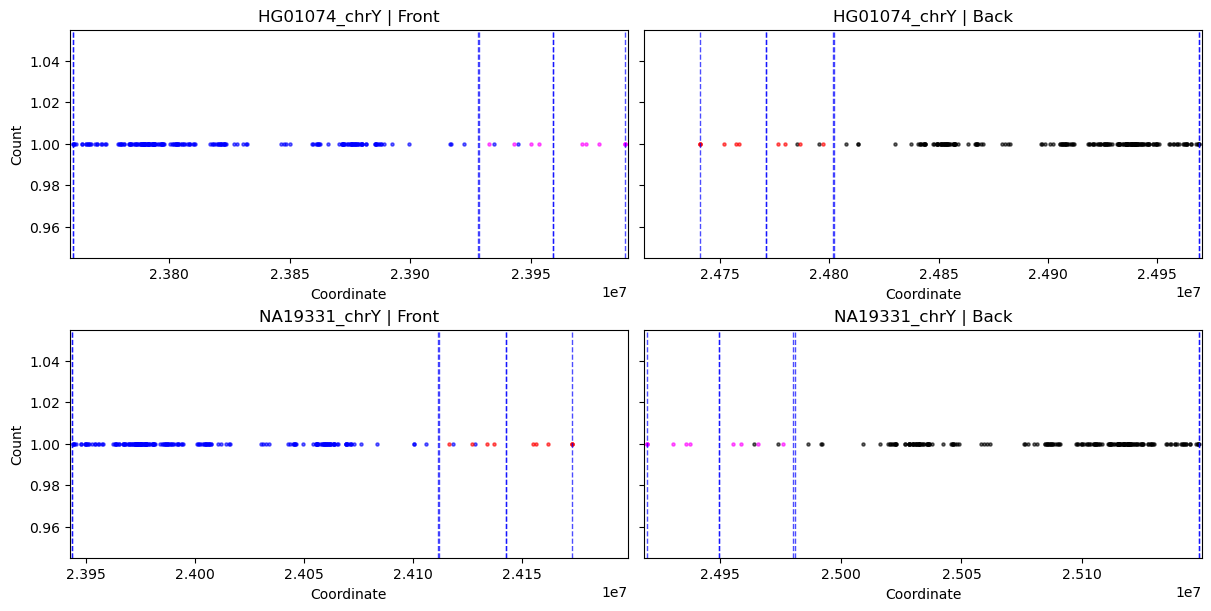

HG02074_HG02392_b2b3Inversion_breakpoint.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8246/3537336931.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


144: SAME
319: SAME
585: SAME
826: SAME
1500: SAME
4037: SAME
5622: SAME
5643: SAME
6274: SAME
6666: SAME
7051: SAME
9174: SAME
10116: SAME
10140: SAME
13470: SAME
15960: SAME
18638: SAME
19327: SAME
19703: SAME
19896: SAME
19998: SAME
20149: SAME
20358: SAME
21144: SAME
21214: SAME
23207: SAME
23311: SAME
23646: SAME
23818: SAME
24136: SAME
24198: SAME
24933: SAME
26001: SAME
26136: SAME
26680: SAME
26852: SAME
27391: SAME
27861: SAME
28217: SAME
28354: SAME
28422: SAME
28505: SAME
28583: SAME
28840: SAME
28990: SAME
29204: SAME
29364: SAME
29381: SAME
29429: SAME
29488: SAME
29856: SAME
29872: SAME
30040: SAME
30423: SAME
30761: SAME
31303: SAME
31400: SAME
31631: SAME
31709: SAME
31768: SAME
32356: SAME
32575: SAME
33123: SAME
33145: SAME
33315: SAME
33402: SAME
33619: SAME
33703: SAME
33705: SAME
33707: SAME
33709: SAME
33711: SAME
34257: SAME
34497: SAME
35209: SAME
35718: SAME
36638: SAME
36731: SAME
36801: SAME
36826: SAME
37108: SAME
37413: SAME
37612: SAME
37858: SAME
40176: S

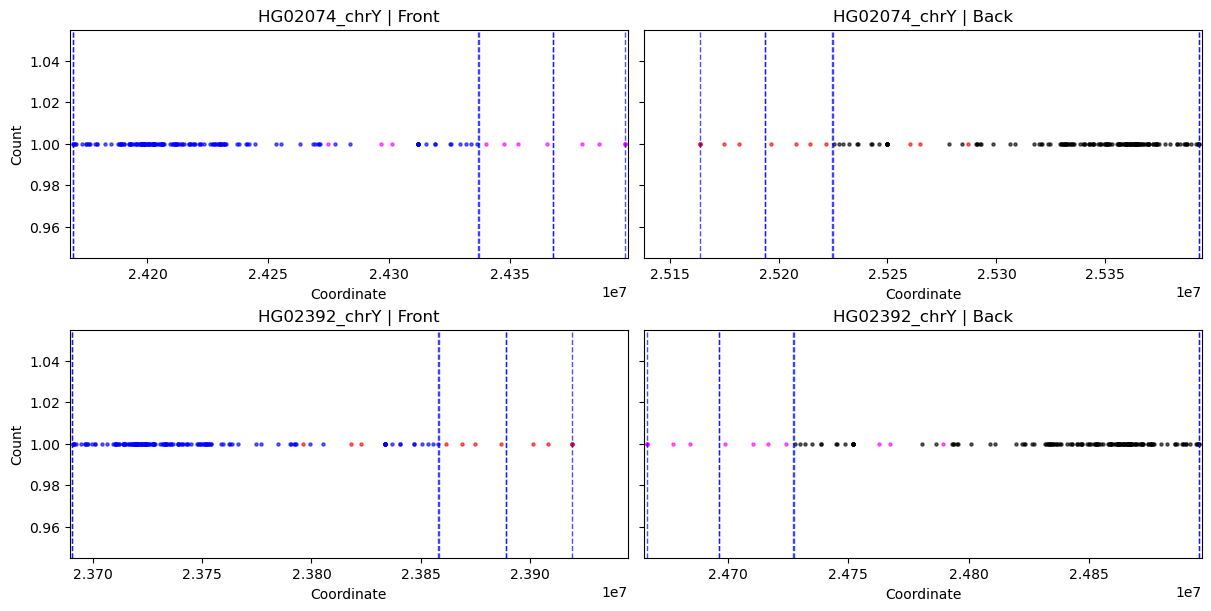

NA20870_HG03579_b2b3Inversion_breakpoint.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8246/3537336931.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


144: SAME
319: SAME
585: SAME
699: SAME
1499: SAME
4036: SAME
5621: SAME
5642: SAME
6273: SAME
6665: SAME
7050: SAME
7438: SAME
9173: SAME
10115: SAME
10139: SAME
13469: SAME
18656: SAME
19345: SAME
19914: SAME
20167: SAME
20376: SAME
21162: SAME
23329: SAME
23664: SAME
23836: SAME
24154: SAME
24216: SAME
24951: SAME
26019: SAME
26698: SAME
26848: SAME
26870: SAME
27409: SAME
27879: SAME
28235: SAME
28372: SAME
28440: SAME
28523: SAME
28601: SAME
28651: SAME
28858: SAME
29008: SAME
29222: SAME
29382: SAME
29399: SAME
29447: SAME
29506: SAME
29874: SAME
29890: SAME
30058: SAME
30441: SAME
30779: SAME
31321: SAME
31418: SAME
31649: SAME
31709: SAME
31727: SAME
31786: SAME
32374: SAME
32593: SAME
33141: SAME
33163: SAME
33333: SAME
33420: SAME
33637: SAME
34278: SAME
34518: SAME
35230: SAME
35739: SAME
36659: SAME
36752: SAME
36822: SAME
36847: SAME
37129: SAME
37434: SAME
37633: SAME
37879: SAME
40197: SAME
41000: SAME
41533: SAME
42053: SAME
42392: SAME
42656: SAME
43001: SAME
43002: SA

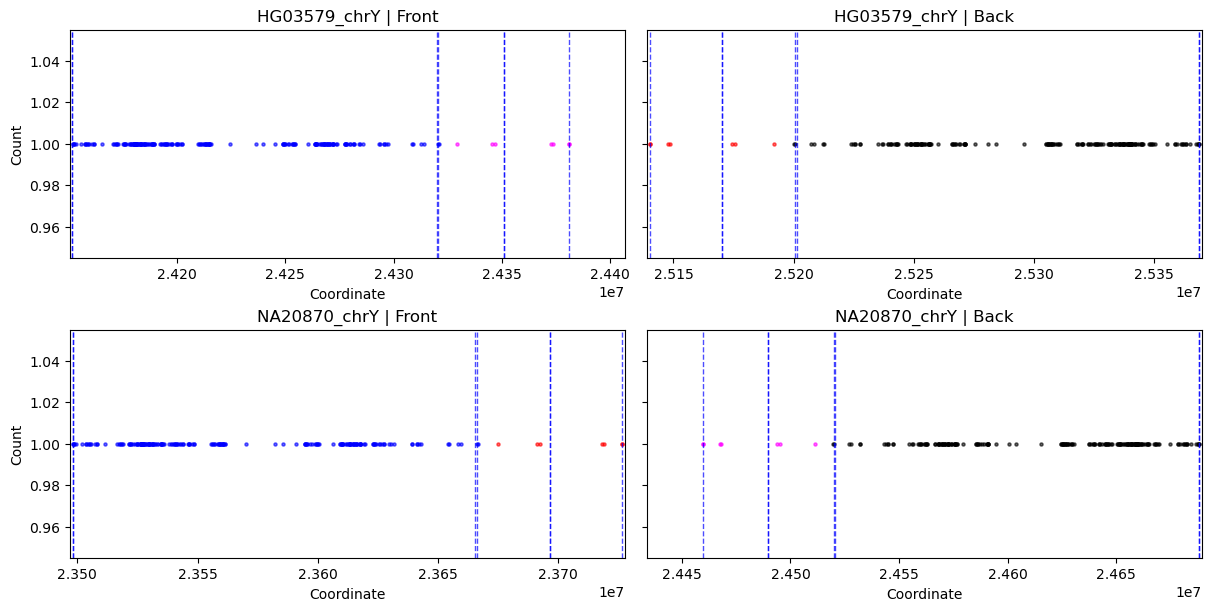

NA21093_HG03009_b2b3Inversion_breakpoint.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8246/3537336931.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


144: SAME
319: SAME
585: SAME
699: SAME
1499: SAME
1745: SAME
4035: SAME
5620: SAME
5641: SAME
6272: SAME
6664: SAME
7049: SAME
9172: SAME
10114: SAME
10138: SAME
11730: SAME
11989: SAME
13468: SAME
18636: SAME
19325: SAME
19701: SAME
19894: SAME
20147: SAME
20356: SAME
21142: SAME
21212: SAME
23210: SAME
23225: SAME
23309: SAME
23644: SAME
23816: SAME
24134: SAME
24196: SAME
24931: SAME
25999: SAME
26134: SAME
26678: SAME
26850: SAME
27389: SAME
27859: SAME
28352: SAME
28420: SAME
28503: SAME
28581: SAME
28838: SAME
28988: SAME
29202: SAME
29362: SAME
29379: SAME
29428: SAME
29487: SAME
29855: SAME
29871: SAME
30039: SAME
30422: SAME
30760: SAME
31302: SAME
31399: SAME
31630: SAME
31695: SAME
31709: SAME
31768: SAME
32356: SAME
32575: SAME
33123: SAME
33145: SAME
33315: SAME
33402: SAME
33619: SAME
34102: SAME
34259: SAME
34499: SAME
35211: SAME
35720: SAME
36640: SAME
36733: SAME
36803: SAME
36828: SAME
37110: SAME
37415: SAME
37614: SAME
37860: SAME
40178: SAME
46481: SAME
48695: SA

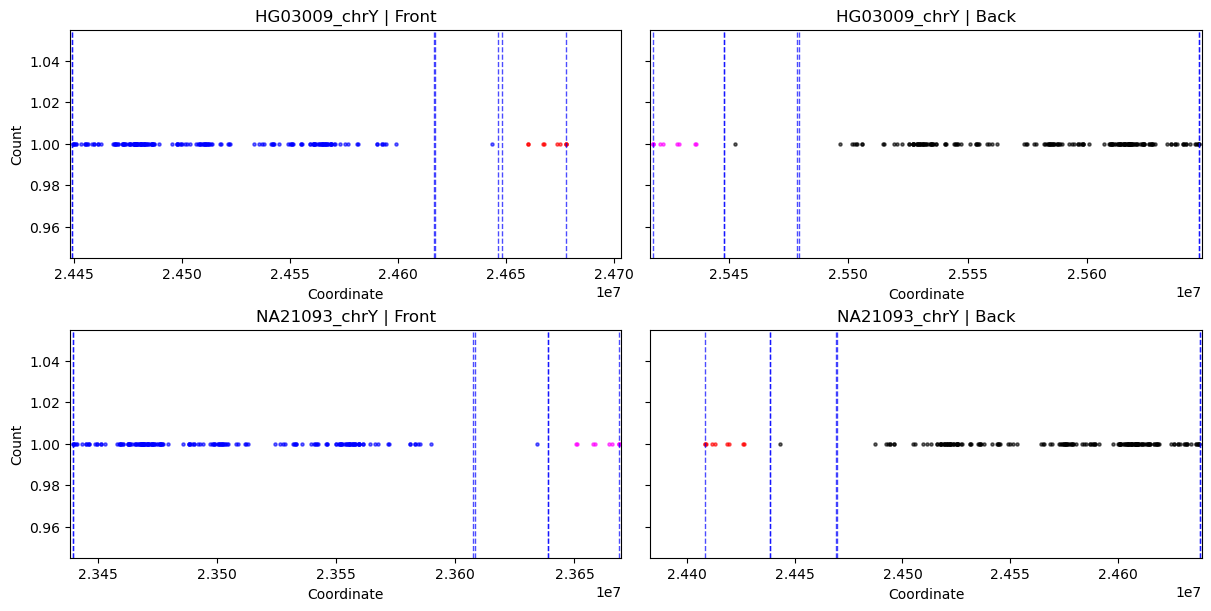

HG01109_NA19331_b2b3Inversion_breakpoint.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8246/3537336931.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


8: SAME
144: SAME
319: SAME
585: SAME
699: SAME
1499: SAME
3875: SAME
4036: SAME
5621: SAME
5642: SAME
6273: SAME
6342: SAME
6665: SAME
7050: SAME
7439: SAME
9174: SAME
10116: SAME
10140: SAME
11715: SAME
11974: SAME
13453: SAME
13880: SAME
18621: SAME
19310: SAME
19686: SAME
19879: SAME
20132: SAME
20341: SAME
21127: SAME
21197: SAME
23190: SAME
23294: SAME
23629: SAME
23801: SAME
24119: SAME
24181: SAME
24916: SAME
25792: SAME
25984: SAME
26119: SAME
26529: SAME
26533: SAME
26537: SAME
26663: SAME
26835: SAME
27374: SAME
27844: SAME
28337: SAME
28405: SAME
28488: SAME
28566: SAME
28823: SAME
28973: SAME
29187: SAME
29347: SAME
29364: SAME
29412: SAME
29471: SAME
29839: SAME
29855: SAME
30023: SAME
30406: SAME
30744: SAME
31286: SAME
31383: SAME
31614: SAME
31674: SAME
31692: SAME
31751: SAME
32339: SAME
32558: SAME
32717: SAME
33106: SAME
33128: SAME
33298: SAME
33385: SAME
33602: SAME
33686: SAME
33688: SAME
33690: SAME
33692: SAME
33694: SAME
34240: SAME
34480: SAME
35192: SAME
357

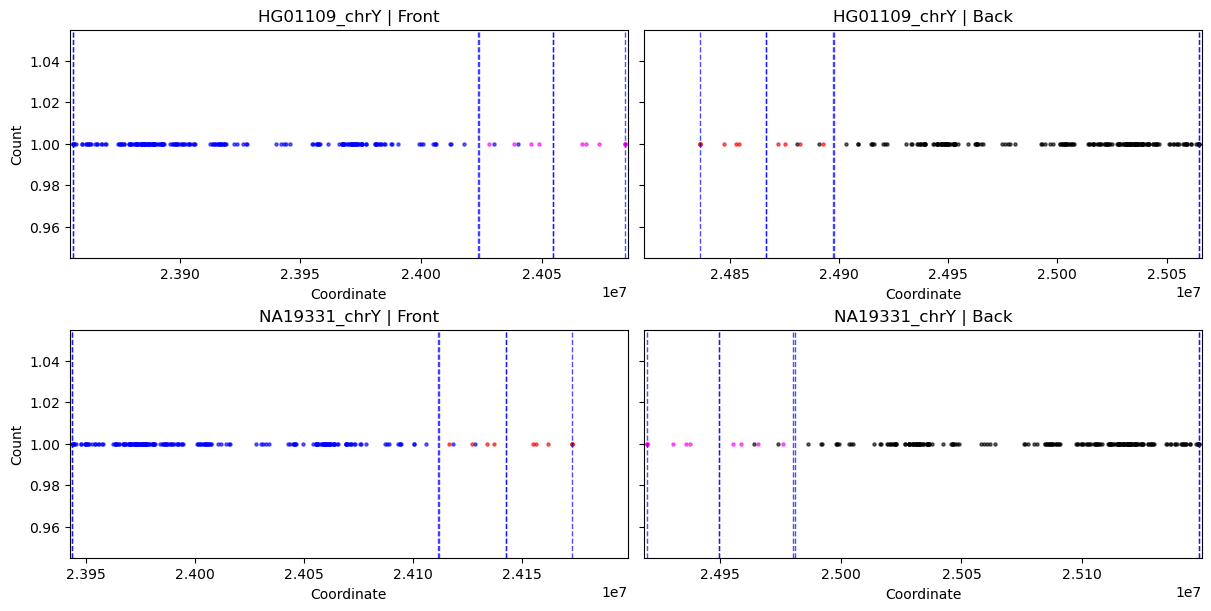

In [34]:
import numpy as np
import collections

directory='/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/b2b3Inversion/alignments/'
for fastaFile in os.listdir(directory):
    if '.fasta' in fastaFile:
        print(fastaFile)
        outFilePath = '/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/b2b3Inversion/dataframes/T2TvsGRCh38_'+str(fastaFile.split(".fasta")[0])+".csv"
        outFileIMG = '/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/b2b3Inversion/dataframes/T2TvsGRCh38_'+str(fastaFile.split(".fasta")[0])+".pdf"
        df_wide = msa_fasta_to_df(directory+fastaFile)
        
        coordinateDict = {r: {} for r in df_wide.index}
        for r in df_wide.index:
            rlow = str(r).lower()
            region = r.split(":", 1)[1]
            a, b = region.split("-", 1)
            start_bp = int(a)
            end_bp   = int(b.split("_", 1)[0])  
        
            if "_front" in rlow:
                coord = start_bp
                step = 1
            elif "_back" in rlow:
                coord = end_bp
                step = -1
            else:
                raise ValueError(f"Row missing _front/_back suffix: {r}")
        
            for c in df_wide.columns:
                if df_wide.at[r, c] == "-":
                    continue
                coordinateDict[r][c] = coord
                coord += step
        
        df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()
        interestingColumns=[]
        for column in df_wide2.columns:
            if len(set(df_wide2[column]))==1:
                continue
            else:
                interestingColumns.append(column)

        newDF = df_wide[interestingColumns].copy()

        pairs = pair_front_back_different_samples(list(newDF.index))

        newList=[]
        for column in newDF.columns:
            tempDict = collections.Counter(newDF[column])
            
            if len(tempDict)==2 and tempDict[list(tempDict.keys())[0]]==2:
                
                if newDF.at[pairs[0][0],column]==newDF.at[pairs[0][1],column]:
                    print(str(column)+": FRONT-BACK2")
                    newList.append([pairs[0][0], coordinateDict[pairs[0][0]][column], 1, 'magenta', 'INV_SNP'])
                    newList.append([pairs[0][1], coordinateDict[pairs[0][1]][column], 1, 'magenta', 'INV_SNP'])
                    newList.append([pairs[1][0], coordinateDict[pairs[1][0]][column], 1, 'red', 'INV_SNP'])
                    newList.append([pairs[1][1], coordinateDict[pairs[1][1]][column], 1, 'red', 'INV_SNP'])
                else:
                    print(str(column)+": SAME")
                    newList.append([pairs[0][0], coordinateDict[pairs[0][0]][column], 1, 'blue', 'SHARED_SNP'])
                    newList.append([pairs[0][1], coordinateDict[pairs[0][1]][column], 1, 'black', 'SHARED_SNP'])
                    newList.append([pairs[1][0], coordinateDict[pairs[1][0]][column], 1, 'blue', 'SHARED_SNP'])
                    newList.append([pairs[1][1], coordinateDict[pairs[1][1]][column], 1, 'black', 'SHARED_SNP'])

        finalCountDF = pd.DataFrame(data=newList, columns=['Sample', 'Coordinate', 'Hit', 'MatchType', 'SNPtype'])

        testDF = finalCountDF.sort_values(by=['Sample','Coordinate']).copy()
        tempDFList=[]
        for sample in set(testDF['Sample']):
            tempDF = testDF[testDF['Sample']==sample].copy()
        
            sampleList=[]
            tempList=[]
            for row in tempDF.index:
                coordinate = tempDF.at[row,'Coordinate']
                if len(tempList) == 0:
                    tempList.append(coordinate)
                    snpType = tempDF.at[row,'SNPtype']
        
                else:
                    if tempDF.at[row,'SNPtype'] == snpType:
                        tempList.append(coordinate)
                    else:
                        tempDFList.append([sample.split(":")[0].split("_")[0],sample.split("_")[-1], len(tempList),min(tempList), max(tempList), max(tempList)-min(tempList), snpType])
                        tempList = []
                        tempList.append(coordinate)
                        snpType = tempDF.at[row,'SNPtype']
        
            if len(tempList) >0:
                tempDFList.append([sample.split(":")[0].split("_")[0],sample.split("_")[-1], len(tempList), min(tempList), max(tempList), max(tempList)-min(tempList),snpType])

        windowDF = pd.DataFrame(data=tempDFList, columns=['Sample','Side','SNPCount','Start','End','WindowSize','SNPtype'])  
        windowDF.sort_values(by=['Sample','Start'], inplace=True)
        windowDF2 = add_breakpoint_windows(windowDF)
        windowDF2['ColorBlocks']='TEMP'
        windowDF2['ColorBlock_Coord']='TEMP'

        vlines={}
        for sample in set(finalCountDF['Sample']):
            side = sample.split("_")[-1]
            contig = sample.split(":")[0]
            startcoord = int(sample.split(":")[1].split("-")[0])
            endcoord = int(sample.split(":")[1].split("-")[1].split("_")[0])
            
            df2 = df[(df['contig']==contig)].copy()
            goodRows=[]
            for row,start,end in zip(df2.index, df2['start'], df2['end']):
                if start < endcoord and end > startcoord:
                    goodRows.append(row)
            df3 = df2.loc[goodRows].copy()
            coords=[x+1 for x in df3['start']]
            for y in df3['end']:
                coords.append(y-1)
            vlines[(contig, side)]=sorted(coords)
            


        for sample in set(windowDF2['Sample']):
            windowDF3 = windowDF2[windowDF2['Sample'] == sample].copy()
            blockDF = df[df['contig'] == sample + "_chrY"].copy()
        
            for row in windowDF3.index:
                start = int(windowDF3.at[row, 'Start'])
                end   = int(windowDF3.at[row, 'End'])
                side  = str(windowDF3.at[row, 'Side']).lower()
        
                w_lo, w_hi = (start, end) if start <= end else (end, start)
        
                temp_blocks = []
                temp_coords = []  
        
                for row2 in blockDF.index:
                    blockstart = int(blockDF.at[row2, 'start'])
                    blockend   = int(blockDF.at[row2, 'end'])
                    colorblock = str(blockDF.at[row2, 'colorblock'])
        
                    ov_lo = max(w_lo, blockstart)
                    ov_hi = min(w_hi, blockend)
        
                    if ov_lo <= ov_hi:
                        temp_blocks.append(colorblock)
        
                        if side == "front":
                            coord_info = {
                                "into_at_start": ov_lo - blockstart,      
                                "into_at_end":   ov_hi - blockstart,      
                                "to_end_from_start": blockend - ov_lo,    
                                "to_end_from_end":   blockend - ov_hi,    
                            }
                        else:  
                            coord_info = {
                                "into_at_start": blockend - ov_hi,       
                                "into_at_end":   blockend - ov_lo,        
                                "to_start_from_start": ov_hi - blockstart,
                                "to_start_from_end":   ov_lo - blockstart,
                            }
        
                        temp_coords.append(coord_info)
        
                windowDF2.at[row, 'ColorBlocks'] = temp_blocks
                windowDF2.at[row, 'ColorBlock_Coord'] = temp_coords


        nearestWindows=[]
        for side in ['Front','Back']:
            for sample in set(windowDF2['Sample']):
                tempTestDF = windowDF2[(windowDF2['Sample']==sample) & (windowDF2['Side']==side) & (windowDF2['SNPtype']=='INV_SNP')].copy()
                tempTestDF.sort_values(by=['WindowSize'], inplace=True, ascending=False)
        
                indexNumber = tempTestDF.iloc[0].name
                if side == 'Back':
                    nearestWindows.append(indexNumber+1)
                else:
                    nearestWindows.append(indexNumber-1)
                    
        bwinDF = windowDF2.loc[nearestWindows].copy()
        bwinDF['Designator']='LARGE_INV_SNP_WINDOW'

        endWindows=[]
        for side in ['Front','Back']:
            for sample in set(windowDF2['Sample']):
                tempTestDF = windowDF2[(windowDF2['Sample']==sample) & (windowDF2['Side']==side) & (windowDF2['SNPtype']=='INV_SNP')].copy()
        
                
                if side == 'Back':
                    indexNumber = tempTestDF.iloc[0].name
                    endWindows.append(indexNumber+1)
                    
                else:
                    indexNumber = tempTestDF.iloc[-1].name
                    endWindows.append(indexNumber-1)

        endwinDF = windowDF2.loc[endWindows].copy()
        endwinDF['Designator']='LAST_INV_SNP_WINDOW'


        winDFs = [bwinDF,endwinDF]
        finalWindowDF = pd.concat(winDFs)
        finalWindowDF.sort_values(by=['Sample','Start'], inplace=True)
        finalWindowDF.reset_index(inplace=True)

        finalWindowDF['Repeats']='NONE_FOUND'
        for sample in finalWindowDF["Sample"].unique():
            rmDF = pd.read_csv(rmDict[sample], sep="\t").copy()
        
            rmDF["query_match_start"] = pd.to_numeric(rmDF["query_match_start"], errors="coerce")
            rmDF["query_match_end"]   = pd.to_numeric(rmDF["query_match_end"], errors="coerce")
            rmDF = rmDF.dropna(subset=["query_match_start", "query_match_end"])
        
            tempWindows = finalWindowDF[finalWindowDF["Sample"] == sample].copy()
        
            for w_idx in tempWindows.index:
                start = int(tempWindows.at[w_idx, "Start"])
                end   = int(tempWindows.at[w_idx, "End"])
                w_lo, w_hi = (start, end) if start <= end else (end, start)
        
                mask = (rmDF["query_match_start"] <= w_hi) & (rmDF["query_match_end"] >= w_lo)
                ov = rmDF.loc[mask].copy()
                ov['Size']=ov['query_match_end']-ov['query_match_start']
        
                tempHolder=[]
                for repeat, orientation, size in zip(ov['repeat_motif_name'], ov['match_orientation'], ov['Size']):
                    tempHolder.append(str(repeat)+"~"+str(orientation)+"~"+str(size))
        
                
                finalWindowDF.at[w_idx,'Repeats']=tempHolder

        finalWindowDF.to_csv(outFilePath)
        plot_front_back_quadrants(finalCountDF, vlines=vlines, outFile=outFileIMG)

## Read in the datframes you just made

In [43]:
df1 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/b2b3Inversion/dataframes/T2TvsGRCh38_HG01074_NA19331_b2b3Inversion_breakpoint.csv')
df2 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/b2b3Inversion/dataframes/T2TvsGRCh38_HG01109_NA19331_b2b3Inversion_breakpoint.csv')
df3 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/b2b3Inversion/dataframes/T2TvsGRCh38_HG02074_HG02392_b2b3Inversion_breakpoint.csv')
df4 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/b2b3Inversion/dataframes/T2TvsGRCh38_NA20870_HG03579_b2b3Inversion_breakpoint.csv')
df5 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/b2b3Inversion/dataframes/T2TvsGRCh38_NA21093_HG03009_b2b3Inversion_breakpoint.csv')

In [44]:
myconcatList = [df1,df2,df3,df4,df5]
concatDF = pd.concat(myconcatList).reset_index().drop(columns=['index','Unnamed: 0','level_0'])

In [45]:
samplesWithInversion=['HG01109','HG01074','NA20870','NA21093','HG02074']

In [46]:
frontDF = concatDF[(concatDF['Sample'].isin(samplesWithInversion)) & (concatDF['Side']=='Front')].copy()
backDF = concatDF[(concatDF['Sample'].isin(samplesWithInversion)) & (concatDF['Side']=='Back')].copy()

checkedFrontDF = frontDF[frontDF['Designator']=='LARGE_INV_SNP_WINDOW'].copy()
checkedbackDF = backDF[backDF['Designator']=='LARGE_INV_SNP_WINDOW'].copy()

In [47]:
newConcatList = [checkedFrontDF,checkedbackDF]
myFinalBWDF = pd.concat(newConcatList).reset_index().drop(columns=['index'])

In [49]:
#myFinalBWDF.to_csv("/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/b2b3Inversion/b2b3_FINAL_breakpointWindows.csv")

In [40]:
import ast
for row in checkedFrontDF.index:
    print(checkedFrontDF.at[row,'Sample'])
    print(checkedFrontDF.at[row,'ColorBlocks'])
    myListDict = ast.literal_eval(str(checkedFrontDF.at[row,'ColorBlock_Coord']))
    if len(myListDict)>1:
        myFirstKey = myListDict[0]
        mySecondKey = myListDict[1]
        print('From End: '+str(myFirstKey['to_end_from_start']))
        print('From Start: '+str(mySecondKey['into_at_end']))
    else:
        print('ONE')
        myFirstKey = myListDict[0]
        mySecondKey = myListDict[0]
        print('From Start: '+str(myFirstKey['into_at_start']))
        print('From Start: '+str(mySecondKey['into_at_end']))

    print('\n')

HG01074
['blue3-plus']
ONE
From Start: 16476
From Start: 21839


HG01109
['blue3-plus']
ONE
From Start: 16476
From Start: 21839


HG02074
['blue2', 'blue4-plus']
From End: 388
From Start: 3030


NA20870
['blue4-plus']
ONE
From Start: 723
From Start: 8760


NA21093
['blue4-plus', 'blue3-bIR1-3']
From End: 4444
From Start: 11982




In [ ]:
#Blue - plus only:
Pink Ball =   HG01074 = 16476 - 16476
              HG01109 = 16476 - 21839
                  
#blue-plus->IR1         
        ORANGE BALL = NA21093 = 16476 - 21839
#Blue -> blue-plus
Green Ball =  HG02074 = 388 - 3030 blue to plus
              NA20870 = 723 - 8760 plus only

In [17]:
print(frontDF.at[16,'Repeats'])
print(frontDF.at[16,'Sample'])

['SVA_A~-1~248', 'A-rich~1~47', 'AluJb~-1~319', 'L1MA4~-1~171', 'L1MA4~1~78', 'L1M3de~1~286', 'AluSx1~-1~265', 'L1M3de~1~20', 'MSTB1~1~431', 'AluSc8~-1~322', 'L1M3b~1~460']
HG02074


In [18]:
print(frontDF.at[28,'Repeats'])
print(frontDF.at[28,'Sample'])

['AluSx1~-1~265', 'MSTB1~1~431', 'AluSc8~-1~322', 'L1M3b~1~460', 'L1PREC2~1~117', '(AC)n~1~23', '(TTCC)n~1~133', 'AluSz~-1~308', 'AluSz~-1~307', 'MLT1F~-1~112', '(ATAA)n~1~36', '(TTTACT)n~1~31']
NA20870


In [ ]:
'AluSx1~-1~265', 'L1M3de~1~20', 'MSTB1~1~431', 'AluSc8~-1~322', 'L1M3b~1~460'
'AluSx1~-1~265',                'MSTB1~1~431', 'AluSc8~-1~322', 'L1M3b~1~460'